 Step 1: Loading raw data and generating heuristic ground-truth labels...
 Step 2: Initiating parallelized Hyperparameter Grid Search...
 Optimization Matrix Complete! Best Param Combination Found:
{'svm__C': 1.0, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}

 Step 3: Generating performance classification matrix details...

=== OPTIMIZED LINEAR SVM PERFORMANCE ===
                     precision    recall  f1-score   support

Policy / Non-Attack       0.72      0.62      0.67        42
    Personal Attack       0.85      0.90      0.88       101

           accuracy                           0.82       143
          macro avg       0.79      0.76      0.77       143
       weighted avg       0.81      0.82      0.81       143

Step 4: Generating diagnostic confusion matrix graphics...


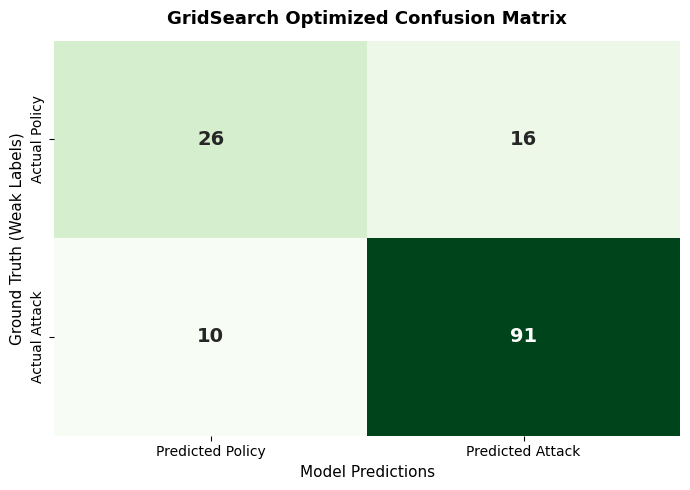

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# STEP 1: INITIALIZE DATA & AUTOMATED 10-POINT LABELING ENGINE
# ==============================================================================
print(" Step 1: Loading raw data and generating heuristic ground-truth labels...")
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# Defining the 10 core analytical rules based on your framework
linguistic_rules = {
    'Q1_Character_Integrity': [r'corrupt', r'cheat', r'untrustworthy', r'fake', r'fraud'],
    'Q2_Personal_Traits': [r'arrogant', r'ego', r'selfish', r'coward', r'weak'],
    'Q3_Ridicule_Mockery': [r'joke', r'laughable', r'clown', r'ridiculous', r'nonsense'],
    'Q4_Derogatory_Language': [r'fool', r'stupid', r'idiot', r'loser', r'liar'],
    'Q5_Misconduct_Criminality': [r'scam', r'bribe', r'loot', r'theft', r'scandal', r'criminal', r'mafia'],
    'Q6_Emotional_Outbursts': [r'hate', r'disgusting', r'horrible', r'shame', r'outrageous'],
    'Q7_Incompetence_Fitness': [r'incompetent', r'clueless', r'unfit', r'dumb', r'incapable'],
    'Q8_Family_Personal_Life': [r'son', r'daughter', r'wife', r'family', r'dynasty', r'nepotism'],
    'Q9_Physical_Appearance': [r'sick', r'old', r'looks', r'physical', r'health'],
    'Q10_Guilt_By_Association': [r'puppet', r'handler', r'gang', r'syndicate', r'nexus']
}
criteria_cols = list(linguistic_rules.keys())

def map_attack_dimensions(text):
    text_lower = str(text).lower()
    scores = {}
    for question_id, patterns in linguistic_rules.items():
        match_count = sum(len(re.findall(r'\b' + pattern + r'\b', text_lower)) for pattern in patterns)
        scores[question_id] = match_count
    return pd.Series(scores)

# Generate features and bootstrap automated binary targets
dimensional_metrics = df['text'].apply(map_attack_dimensions)
df = pd.concat([df, dimensional_metrics], axis=1)
df['label'] = (df[criteria_cols].sum(axis=1) > 0).astype(int)

# ==============================================================================
# STEP 2: TRAIN-TEST SPLIT PREPARATION
# ==============================================================================
X = df['text'].fillna('').astype(str)
y = df['label']

# Stratify=y keeps class ratios identical between sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# ==============================================================================
# STEP 3: PIPELINE DESIGN & GRID SEARCH CROSS-VALIDATION (STRATEGY 3)
# ==============================================================================
print(" Step 2: Initiating parallelized Hyperparameter Grid Search...")

# Bundle vectorizer and classifier together into an execution pipeline
text_clf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, dual=False))
])

# Define parameter grid combinations to test
param_grid = {
    'tfidf__max_features': [3000, 5000],          # Limit total feature dimensions
    'tfidf__ngram_range': [(1, 1), (1, 2)],        # Test pure words vs word + bigram pairs
    'svm__C': [0.1, 1.0, 10.0]                     # Test soft vs strict margin regularization
}

# Run optimization across 5 cross-validation folds using all CPU cores
grid_search = GridSearchCV(text_clf_pipeline, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f" Optimization Matrix Complete! Best Param Combination Found:\n{grid_search.best_params_}")

# Extract the absolute best performing machine learning estimator
best_predictor = grid_search.best_estimator_

# ==============================================================================
# STEP 4: MODEL EVALUATION & METRIC REPORTING
# ==============================================================================
print("\n Step 3: Generating performance classification matrix details...")
y_pred = best_predictor.predict(X_test)

print("\n=== OPTIMIZED LINEAR SVM PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=['Policy / Non-Attack', 'Personal Attack']))

# ==============================================================================
# STEP 5: VISUALIZE CRISP PERFORMANCE MATRICES (SEABORN HEATMAP)
# ==============================================================================
print("Step 4: Generating diagnostic confusion matrix graphics...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Predicted Policy', 'Predicted Attack'],
    yticklabels=['Actual Policy', 'Actual Attack'],
    cbar=False,
    annot_kws={'size': 14, 'weight': 'bold'}
)
plt.title("GridSearch Optimized Confusion Matrix", fontsize=13, weight='bold', pad=12)
plt.ylabel("Ground Truth (Weak Labels)", fontsize=11)
plt.xlabel("Model Predictions", fontsize=11)
plt.tight_layout()
plt.savefig('/content/svm_confusion_matrix.png', dpi=300)
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# --- Assuming df is loaded and 'label' is already engineered as per your Step 1 ---
X = df['text'].fillna('').astype(str)
y = df['label']

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 1. EXPANDED PIPELINE DESIGN
# We include sublinear_tf=True to scale down the impact of highly repetitive words
enhanced_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)),
    ('svm', LinearSVC(class_weight='balanced', random_state=42, dual=False, max_iter=2000))
])

# Expanded optimization boundaries based on baseline performance limits
expanded_param_grid = {
    'tfidf__max_features': [3000, 5000, 10000],       # Testing higher feature capacity
    'tfidf__ngram_range': [(1, 2), (1, 3)],           # Extending to trigrams to capture phrase context
    'svm__C': [0.01, 0.1, 1.0, 5.0]                   # Wider regularization search space
}

print("Executing Expanded Hyperparameter Grid Search...")
grid_search = GridSearchCV(enhanced_pipeline, expanded_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Optimal Configuration Discovered: {grid_search.best_params_}")

# 2. EVALUATION
y_pred = best_model.predict(X_test)
print("\n=== ENHANCED MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=['Policy / Non-Attack', 'Personal Attack']))

# 3. EXPLAINABILITY: EXTRACTING GLOBAL FEATURE IMPORTANCE
# Since LinearSVC uses a linear kernel, we can directly extract feature coefficients
vectorizer = best_model.named_steps['tfidf']
classifier = best_model.named_steps['svm']

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_[0]

# Sort coefficients to find top words for both classes
top_attack_indices = np.argsort(coefficients)[-15:]      # Highest positive weights = Attack
top_policy_indices = np.argsort(coefficients)[:15]       # Lowest negative weights = Policy

# Combine for visualization
top_indices = np.concatenate([top_policy_indices, top_attack_indices])
top_features = feature_names[top_indices]
top_coefficients = coefficients[top_indices]

# Plot Feature Importances
plt.figure(figsize=(10, 8))
colors = ['#4C72B0' if c < 0 else '#C44E52' for c in top_coefficients]
plt.barh(top_features, top_coefficients, color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Model Explainability: Top Feature Coefficients", fontsize=14, weight='bold')
plt.xlabel("Coefficient Weight (Negative: Policy | Positive: Personal Attack)", fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance_explainability.png', dpi=300)
plt.close()
print("Saved feature explainability chart to 'feature_importance_explainability.png'")

Executing Expanded Hyperparameter Grid Search...
Optimal Configuration Discovered: {'svm__C': 1.0, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 3)}

=== ENHANCED MODEL PERFORMANCE ===
                     precision    recall  f1-score   support

Policy / Non-Attack       0.78      0.76      0.77        42
    Personal Attack       0.90      0.91      0.91       101

           accuracy                           0.87       143
          macro avg       0.84      0.84      0.84       143
       weighted avg       0.87      0.87      0.87       143

Saved feature explainability chart to 'feature_importance_explainability.png'


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

# 1. PREPARE MULTI-LABEL TARGET MATRIX
# Convert each framework dimension into its own binary label column (0 or 1)
criteria_cols = [
    'Q1_Character_Integrity', 'Q2_Personal_Traits', 'Q3_Ridicule_Mockery',
    'Q4_Derogatory_Language', 'Q5_Misconduct_Criminality', 'Q6_Emotional_Outbursts',
    'Q7_Incompetence_Fitness', 'Q8_Family_Personal_Life', 'Q9_Physical_Appearance',
    'Q10_Guilt_By_Association'
]

# Ensure values are converted to binary format (0 or 1) per column
Y_multilabel = (df[criteria_cols] > 0).astype(int)
X_text = df['text'].fillna('').astype(str)

# Split data into train and test sets
X_train_m, X_test_m, Y_train_m, Y_test_m = train_test_split(
    X_text, Y_multilabel, test_size=0.20, random_state=42
)

# 2. CONSTRUCT MULTI-OUTPUT PIPELINE
# MultiOutputClassifier wraps an estimator to handle multi-label matrices natively
multilabel_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')),
    ('multilabel_svm', MultiOutputClassifier(LinearSVC(class_weight='balanced', random_state=42, dual=False)))
])

print("Training Multi-Label Classification Pipeline...")
multilabel_pipeline.fit(X_train_m, Y_train_m)

# 3. PREDICT AND EVALUATE EACH INDIVIDUAL DIMENSION
Y_pred_m = multilabel_pipeline.predict(X_test_m)

print("\n=== MULTI-LABEL DIMENSIONAL CLASSIFICATION REPORT ===")
# Generate performance metrics for every single framework category
print(classification_report(Y_test_m, Y_pred_m, target_names=criteria_cols, zero_division=0))

Training Multi-Label Classification Pipeline...

=== MULTI-LABEL DIMENSIONAL CLASSIFICATION REPORT ===
                           precision    recall  f1-score   support

   Q1_Character_Integrity       0.00      0.00      0.00         5
       Q2_Personal_Traits       0.56      0.26      0.36        19
      Q3_Ridicule_Mockery       0.00      0.00      0.00         2
   Q4_Derogatory_Language       0.00      0.00      0.00         1
Q5_Misconduct_Criminality       0.75      0.43      0.55        14
   Q6_Emotional_Outbursts       0.29      0.25      0.27         8
  Q7_Incompetence_Fitness       0.00      0.00      0.00         2
  Q8_Family_Personal_Life       0.67      0.67      0.67        52
   Q9_Physical_Appearance       0.86      0.72      0.79        94
 Q10_Guilt_By_Association       0.00      0.00      0.00         1

                micro avg       0.74      0.59      0.66       198
                macro avg       0.31      0.23      0.26       198
             weighted av